# Práctica 2: Modelo cinemático inverso de un manipulador y planteamiento de trayectoria


## Objetivo



El objetivo de esta práctica es que el alumno comprenda, interprete y modifique el modelo de cinemática directa e inversa d eun moanipulador serial.


### Metas 

- Que el alumno aplique un modelo cinemático, obteniendo las matrices de transformación y la postura del manipulador 
- Que el alumno aplique un modelo cinemático inverso para calcular una trayectoria a partir de una posición actual hacia una posición final
- Que el alumno grafique y analice los resultados del modelo

### Contribución al perfil del egresado

La siguiente práctica contribuye en los siguientes puntos al perfil del egresado:

#### Aptitudes y habilidades

- Para modelar, simular e interpretar el comportamiento de los sistemas mecatrónicos.
- Para diseñar, construir, operar y mantener los sistemas mecatrónicos y sus componentes.

#### Actitudes

- Tener confianza en su preparación académica.
- Comprometido con su actualización, superación y competencia profesional.

#### De tipo social

- Promover el cambio en la mentalidad frente a la competitividad internacional.



## Rúbrica de evaluación



La evaluación de la práctica contará de los siguientes puntos y se evaluará con los siguientes criterios:

| Elemento | Porcentaje |
| ------:| -----------:|
| **Cuestionario previo** | 15% | 
| **Desarrollo** | 35% |
| **Análisis de resultados**  | 35% |
| **Conclusiones** | 15% |

<br>


| Elemento | Malo | Regular | Bueno |
| ------:| ------ | --------| ------|
| **Cuestionario previo** | El trabajo no contiene cuestionario previo o todas las preguntas son incorrectas (0%)| Al menos la mitad de las preguntas son correctas (8%) |  Todas las preguntas son correctas (15%) |
| **Desarrollo** | El trabajo no contiene desarrollo o su planteamiento no concuerda con lo deseado (0%) | El desarrollo está mal planteado o no llega a los resultados esperados (10%) | El desarrollo tiene un planteamiento adecuado y llega a los resultados esperados (35%) |
| **Análisis de resultados**  | El trabajo no contiene análisis de resultados o la información no se está interpretando correctamente (0%) | La interpretación de los resultados es parcial o desorganizada (10%) | Realiza un correcto análisis de los resultados de forma organizada   (35%) |
| **Conclusiones** | El trabajo no contiene conclusiones o no hacen referencia al trabajo desarrollado y los objetivos planteados (0%) | La redacción de las conclusiones es desorganizada o confusa (8%) | Las conclusiones del trabajo son claras y hacen referencia al trabajo desarrollado y los objetivos planteados (15%) | 



## Introducción

### Transformaciones homogéneas
Las transformaciones homogéneas permiten hacer el planteamiento del modelo cinemático de un robot, considerando las posiciones y orientaciones de las juntas del robot respecto al sistema de referencia de una junta anterior

Este planteamiento es el **modelo de cinemática directa**, que nos permite obtener la posición y velocidad del efector final de un manipulador en términos de los valores de la posición y velocidad de sus juntas (espacio de trabajo)

A través de este modelo se puede obtener el **modelo de cinemática inversa**, que permite obtener la velocidad de las juntas de un robot a partir de la velocidad deseada del efector final.

### Planteamiento de una trayectoria
Si se conoce el punto inicial y final de una trayectoria deseada, se pueden obtener los puntos intermedios de la trayectoria. La forma más fácil de realizar esta interpolación es a través de un spline. El orden del spline permitirá controlar las condiciones inicial y final de la posición, velocidad ó aceleración que tendrá el efector final durante el trayecto. 

Juntando la interpolación de la trayectoria y el modelo de la cinemática inversa, se pueden obtener todos los puntos intermedios de la trayectoria que deben seguir las juntas del robot para que el efector final siga una trayectoria.

### Inyección de dependencias en python
Al crear una clase, es posible agregar atributos y métodos a la misma, que se verán reflejados al instanciar un objeto, por ejemplo:

In [6]:
# Se define una clase
class ClaseEjemplo():
  def metodo_original(self):
    print("Metodo original")
# Fuera de la clase, se define un método nuevo
def metodo_inyectado(self):
  print("Método inyectado en la clase")
# Se asigna el método dentro de la clase
ClaseEjemplo.nuevo_metodo = metodo_inyectado
# Al instanciar el objeto, éste contiene el método inyectado
objeto = ClaseEjemplo()
objeto.nuevo_metodo()

Método inyectado en la clase


## Cuestionario previo



Responder de forma breve las siguientes preguntas:

- ¿Que son las transformaciones homogéneas?
>Las transformaciones homogéneas son fundamentales en robótica para representar y manipular la posición y orientación de cuerpos rígidos en el espacio tridimensional. Al combinar la rotación y la traslación en una única matriz de 4×4, estas transformaciones permiten la concatenación fluida de múltiples conversiones de sistemas de coordenadas. 

- ¿Que nos permite obtener el modelo de cinemática directa de un manipulador?
>calcular la posición y orientación del extremo del manipulador (efector final) en el espacio tridimensional, a partir de los valores de las posiciones articulares (ángulos de giro o desplazamientos lineales)

- ¿Que nos permite obtener el modelo de cinemática inversa de un manipulador?
>calcular los ángulos o el desplazamiento de cada articulación necesarios para que el efector final (pinza, herramienta o soldador) alcance una posición y orientación específicas en el espacio de trabajo

- ¿De que formas se puede interpolar la trayectoria de un efector final entre dos puntos?
>La trayectoria del efector final entre dos puntos se puede interpolar de dos formas principales: en el espacio cartesiano (controlando directamente la posición (X, Y, Z) y orientación) o en el espacio articular (interpolando los ángulos de cada motor).

## Desarrollo



### 1. Planteamiento de la cinemática directa
En esta primera parte, se crearán las transformaciones homogéneas y el modelo de cinemática directa de un robot RRR, incluyendo la matriz del Jacobiano. Se recomienda usar **Sympy** para el planteamiento de las expresiones. 
Un diagrama del robot se muestra en la imagen:

<img src="imagenes/p2_1.png" alt = "Robot RRR" width="300" height="300" display= "block"/>

** Considerar valores cualesquiera para las dimensiones de los eslabones y la posición inicial de las juntas

In [7]:
# Colocar y correr el código dentro de estas celdas. 
# Agregar cuantas consideren conveniente

In [8]:
import sympy as sp

# Inicializar el renderizado bonito de ecuaciones en Jupyter
sp.init_printing(use_unicode=True)

# Definir variables simbólicas
# theta1, theta2, theta3: Ángulos de las juntas
# L1, L2, L3: Longitudes de los eslabones
theta1, theta2, theta3 = sp.symbols('theta_1 theta_2 theta_3', real=True)
L1, L2, L3 = sp.symbols('L_1 L_2 L_3', real=True)

print("Variables e inicialización de Sympy completada con éxito.")

Variables e inicialización de Sympy completada con éxito.


In [9]:
def matriz_transformacion(theta, L):
    """
    Retorna la matriz de transformación homogénea 4x4 para una junta 
    rotacional en el plano con un eslabón de longitud L.
    """
    cos_t = sp.cos(theta)
    sin_t = sp.sin(theta)
    
    T = sp.Matrix([
        [cos_t, -sin_t, 0, L*cos_t],
        [sin_t,  cos_t, 0, L*sin_t],
        [    0,      0, 1,       0],
        [    0,      0, 0,       1]
    ])
    return T

# Calcular las transformaciones locales individuales
T01 = matriz_transformacion(theta1, L1)
T12 = matriz_transformacion(theta2, L2)
T23 = matriz_transformacion(theta3, L3)

print("Matrices individuales T01, T12 y T23 calculadas simbólicamente.")

Matrices individuales T01, T12 y T23 calculadas simbólicamente.


In [10]:
# Multiplicación de matrices para la cinemática directa global
T02 = sp.simplify(T01 * T12)
T03 = sp.simplify(T02 * T23)

# Extraer el vector de posición del efector final (X, Y)
# Tomamos la primera fila (X) y segunda fila (Y) de la última columna
x_efector = T03[0, 3]
y_efector = T03[1, 3]

print("--- POSICIÓN DEL EFECTOR FINAL ---")
print(f"X = {x_efector}")
print(f"Y = {y_efector}")

# Mostrar la matriz homogénea completa de forma visualmente atractiva
T03

--- POSICIÓN DEL EFECTOR FINAL ---
X = L_1*cos(theta_1) + L_2*cos(theta_1 + theta_2) + L_3*cos(theta_1 + theta_2 + theta_3)
Y = L_1*sin(theta_1) + L_2*sin(theta_1 + theta_2) + L_3*sin(theta_1 + theta_2 + theta_3)


⎡cos(θ₁ + θ₂ + θ₃)  -sin(θ₁ + θ₂ + θ₃)  0  L₁⋅cos(θ₁) + L₂⋅cos(θ₁ + θ₂) + L₃⋅c
⎢                                                                             
⎢sin(θ₁ + θ₂ + θ₃)  cos(θ₁ + θ₂ + θ₃)   0  L₁⋅sin(θ₁) + L₂⋅sin(θ₁ + θ₂) + L₃⋅s
⎢                                                                             
⎢        0                  0           1                           0         
⎢                                                                             
⎣        0                  0           0                           1         

os(θ₁ + θ₂ + θ₃)⎤
                ⎥
in(θ₁ + θ₂ + θ₃)⎥
                ⎥
                ⎥
                ⎥
                ⎦

In [11]:
# Crear el vector de posición de la tarea
X_pos = sp.Matrix([x_efector, y_efector])

# Crear el vector de variables articulares
q = sp.Matrix([theta1, theta2, theta3])

# Calcular el Jacobiano de forma analítica usando el método jacobian() de Sympy
Jacobiano = X_pos.jacobian(q)

# Simplificar las expresiones algebraicas dentro de la matriz
Jacobiano_simplificado = sp.simplify(Jacobiano)

print("--- MATRIZ JACOBIANA GEOMÉTRICA (J) ---")
Jacobiano_simplificado

--- MATRIZ JACOBIANA GEOMÉTRICA (J) ---


⎡-L₁⋅sin(θ₁) - L₂⋅sin(θ₁ + θ₂) - L₃⋅sin(θ₁ + θ₂ + θ₃)  -L₂⋅sin(θ₁ + θ₂) - L₃⋅s
⎢                                                                             
⎣L₁⋅cos(θ₁) + L₂⋅cos(θ₁ + θ₂) + L₃⋅cos(θ₁ + θ₂ + θ₃)   L₂⋅cos(θ₁ + θ₂) + L₃⋅co

in(θ₁ + θ₂ + θ₃)  -L₃⋅sin(θ₁ + θ₂ + θ₃)⎤
                                       ⎥
s(θ₁ + θ₂ + θ₃)   L₃⋅cos(θ₁ + θ₂ + θ₃) ⎦

### 2. Planteamiento de la trayectoria

En esta segunda parte, se planteará el código que permita definir los puntos intermedios de una trayectoria, la cual debe tener velocidades y aceleraciones nulas al inicio y al final. Se deben incluir también las gráficas de la posición, velocidad y aceleración del efector final. 

Calcular la trayectoria considerando de forma general tiempo de duración, puntos inicial y final, y con una tasa de muestreo de 30 muestras por segundo. 

In [12]:
# Colocar y correr el código dentro de estas celdas. 
# Agregar cuantas consideren conveniente

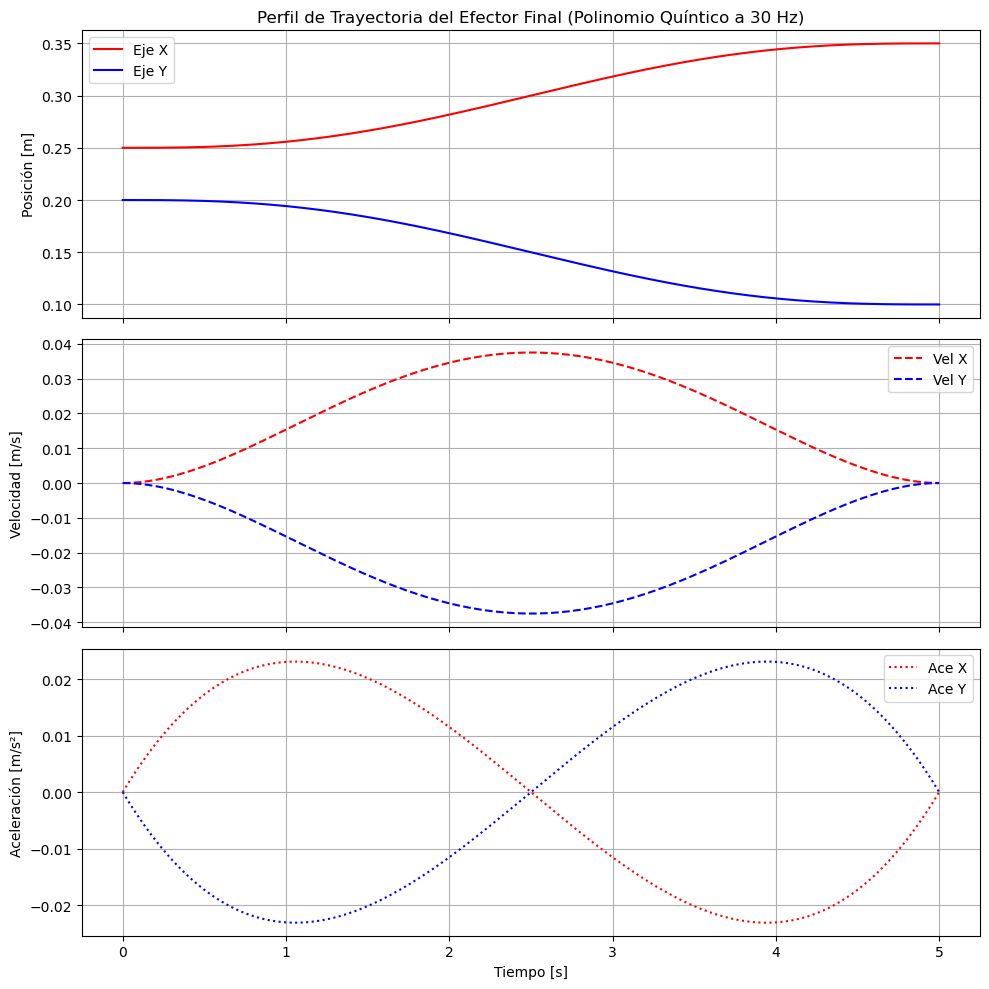

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definición de parámetros generales de la trayectoria
t_inicial = 0.0
t_final = 5.0        # Tiempo total de duración en segundos (ejemplo modificable)
tasa_muestreo = 30   # 30 muestras por segundo (30 Hz)

# Puntos iniciales y finales en el espacio de la tarea (X, Y) en metros
x_inicio, x_fin = 0.25, 0.35
y_inicio, y_fin = 0.20, 0.10

# Calcular el número total de puntos
num_puntos = int((t_final - t_inicial) * tasa_muestreo) + 1
t_vector = np.linspace(t_inicial, t_final, num_puntos)

# 2. Algoritmo de Polinomio Quíntico para asegurar velocidad y aceleración nulas en los extremos
def trayectoria_quintica(p_init, p_mid, t_i, t_f, t):
    """Calcula la posición, velocidad y aceleración en un tiempo t para un polinomio quíntico."""
    T = t_f - t_i
    # Coeficientes del polinomio quíntico deducidos analíticamente para condiciones de frontera nulas
    a0 = p_init
    a1 = 0.0
    a2 = 0.0
    a3 = (10 / T**3) * (p_mid - p_init)
    a4 = (-15 / T**4) * (p_mid - p_init)
    a5 = (6 / T**5) * (p_mid - p_init)
    
    # Evaluar polinomios
    tau = t - t_i
    pos = a0 + a1*tau + a2*tau**2 + a3*tau**3 + a4*tau**4 + a5*tau**5
    vel = a1 + 2*a2*tau + 3*a3*tau**2 + 4*a4*tau**3 + 5*a5*tau**4
    ace = 2*a2 + 6*a3*tau + 12*a4*tau**2 + 20*a5*tau**3
    return pos, vel, ace

# 3. Evaluar la trayectoria a lo largo del tiempo para ambos ejes (X, Y)
x_p, x_v, x_a = [], [], []
y_p, y_v, y_a = [], [], []

for t in t_vector:
    px, vx, ax = trayectoria_quintica(x_inicio, x_fin, t_inicial, t_final, t)
    py, vy, ay = trayectoria_quintica(y_inicio, y_fin, t_inicial, t_final, t)
    
    x_p.append(px); x_v.append(vx); x_a.append(ax)
    y_p.append(py); y_v.append(vy); y_a.append(ay)

# 4. Generación de las Gráficas del Efector Final (Espacio de la Tarea)
fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# Gráfica de Posición
axs[0].plot(t_vector, x_p, 'r-', label='Eje X')
axs[0].plot(t_vector, y_p, 'b-', label='Eje Y')
axs[0].set_ylabel('Posición [m]')
axs[0].set_title('Perfil de Trayectoria del Efector Final (Polinomio Quíntico a 30 Hz)')
axs[0].grid(True)
axs[0].legend()

# Gráfica de Velocidad
axs[1].plot(t_vector, x_v, 'r--', label='Vel X')
axs[1].plot(t_vector, y_v, 'b--', label='Vel Y')
axs[1].set_ylabel('Velocidad [m/s]')
axs[1].grid(True)
axs[1].legend()

# Gráfica de Aceleración
axs[2].plot(t_vector, x_a, 'r:', label='Ace X')
axs[2].plot(t_vector, y_a, 'b:', label='Ace Y')
axs[2].set_xlabel('Tiempo [s]')
axs[2].set_ylabel('Aceleración [m/s²]')
axs[2].grid(True)
axs[2].legend()

plt.tight_layout()
plt.show()

### 3. Cinemática inversa
A partir del modelo de la cinemática directa, obtener la expresión e la cinemática inversa, que relacione las velocidades de las juntas del robot con la velocidad del efector final. Ya que el modelo de cinemática inversa sólo permite obtener velocidades, obtener también expresiones que permitan obtener la posición de las juntas y sus aceleraciones

In [19]:
# Colocar y correr el código dentro de estas celdas. 
# Agregar cuantas consideren conveniente

In [23]:
import sympy as sp
import numpy as np

# 1. Convertir las expresiones simbólicas del Jacobiano y Cinemática Directa a funciones numéricas de NumPy
# Esto nos permite evaluar numéricamente el robot en cada instante de tiempo de la trayectoria
f_jac = sp.lambdify((theta1, theta2, theta3, L1, L2, L3), Jacobiano_simplificado, 'numpy')
f_cin_directa = sp.lambdify((theta1, theta2, theta3, L1, L2, L3), X_pos, 'numpy')

# 2. Definición de parámetros físicos fijos para la simulación del manipulador
# Puedes considerar dimensiones cualesquiera para los eslabones (menores a 0.5m por la p1)
valores_L = {
    'L1': 0.35,  # Metros
    'L2': 0.25,  # Metros
    'L3': 0.15   # Metros
}

# Configuración del diferencial de tiempo (dt) basado en la tasa de muestreo de 30 Hz
dt = 1.0 / 30.0  

# 3. Planteamiento analítico-numérico de la cinemática inversa

def calcular_cinematica_inversa_diferencial(x_deseado, y_deseado, vx_deseada, vy_deseada, q_actual, valores_L):
    l1, l2, l3 = valores_L['L1'], valores_L['L2'], valores_L['L3']
    
    # Evaluar el Jacobiano geométrico en la postura actual
    J_num = f_jac(q_actual[0], q_actual[1], q_actual[2], l1, l2, l3)
    
    # --- MEJORA: Jacobiano Amortiguado (Damped Least Squares) ---
    # Factor de amortiguamiento (lambda). Evita valores infinitos cerca de singularidades
    lam = 0.05 
    
    # Ecuación: J_damped_pseudo = J^T * (J * J^T + lambda^2 * I)^-1
    JJ_T = J_num.dot(J_num.T)
    J_damped_pseudo = J_num.T.dot(np.linalg.inv(JJ_T + lam**2 * np.eye(2)))
    
    v_tarea = np.array([vx_deseada, vy_deseada])
    q_dot = J_damped_pseudo.dot(v_tarea)
    
    return q_dot
print("Expresiones, funciones de conversión a NumPy y algoritmo diferencial de la Sección 3 completados.")

Expresiones, funciones de conversión a NumPy y algoritmo diferencial de la Sección 3 completados.


### 4. Aplicación de la cinemática inversa
Finalmente, a partir de los puntos de la trayectoria y el modelo de cinemática inversa, obtener las posiciones, velocidades y aceleraciones de las juntas del robot, así como sus gráficas en función del tiempo

In [24]:
# Colocar y correr el código dentro de estas celdas. 
# Agregar cuantas consideren conveniente

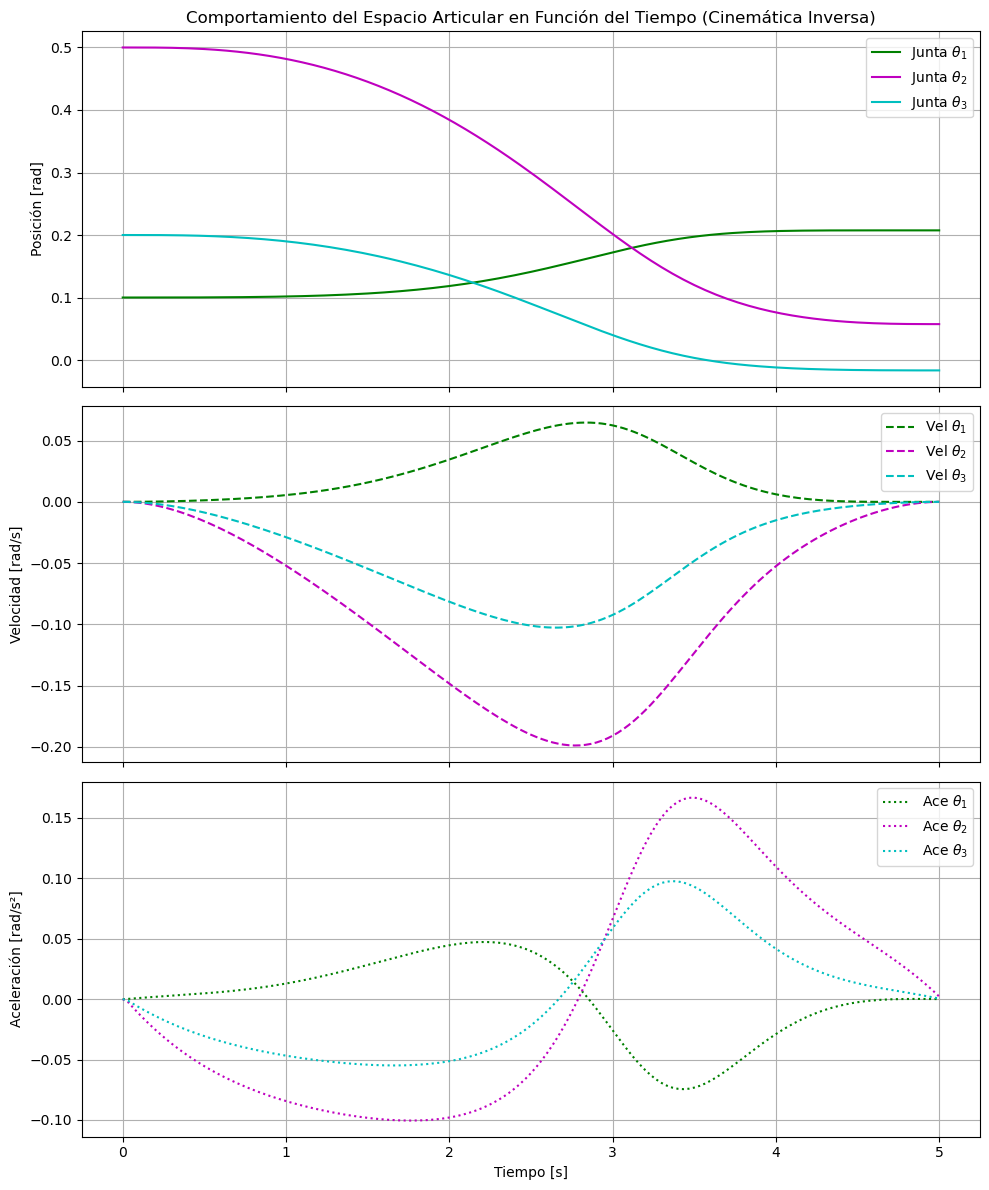

In [25]:
# 1. Definir la postura o condición inicial de las juntas del robot (Valores cualesquiera)
# q0 = [theta1_init, theta2_init, theta3_init] en radianes
q_actual = np.array([0.1, 0.5, 0.2]) 

# Listas para almacenar el histórico de las juntas a lo largo del tiempo
historial_q = []
historial_qdot = []
historial_qddot = []

# 2. Ciclo principal de simulación (Mapeo del espacio de la tarea al espacio articular)
for i in range(len(t_vector)):
    # Extraer las velocidades cartesianas calculadas en la Sección 2
    vx = x_v[i]
    vy = y_v[i]
    
    # Calcular velocidades de las juntas mediante la cinemática inversa diferencial
    q_dot = calcular_cinematica_inversa_diferencial(x_p[i], y_p[i], vx, vy, q_actual, valores_L)
    
    # Calcular las aceleraciones de las juntas mediante diferenciación numérica aproximada (q_ddot)
    if i == 0:
        q_ddot = np.array([0.0, 0.0, 0.0]) # Condición inicial nula
    else:
        q_ddot = (q_dot - historial_qdot[-1]) / dt
        
    # Guardar registros en los historiales
    historial_q.append(q_actual.copy())
    historial_qdot.append(q_dot)
    historial_qddot.append(q_ddot)
    
    # Integración numérica (Método de Euler) para actualizar la posición de la junta en el siguiente paso:
    # q(t + dt) = q(t) + q_dot(t) * dt
    q_actual += q_dot * dt

# Convertir listas a arreglos de NumPy para facilitar el graficado
historial_q = np.array(historial_q)
historial_qdot = np.array(historial_qdot)
historial_qddot = np.array(historial_qddot)

# 3. Generación de las Gráficas del Espacio Articular (Motores del Robot)
fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

colores = ['g', 'm', 'c']
juntas = [r'$\theta_1$', r'$\theta_2$', r'$\theta_3$']

# Gráfica de Posición de las Juntas
for j in range(3):
    axs[0].plot(t_vector, historial_q[:, j], color=colores[j], label=f'Junta {juntas[j]}')
axs[0].set_ylabel('Posición [rad]')
axs[0].set_title('Comportamiento del Espacio Articular en Función del Tiempo (Cinemática Inversa)')
axs[0].grid(True)
axs[0].legend()

# Gráfica de Velocidad de las Juntas
for j in range(3):
    axs[1].plot(t_vector, historial_qdot[:, j], color=colores[j], linestyle='--', label=f'Vel {juntas[j]}')
axs[1].set_ylabel('Velocidad [rad/s]')
axs[1].grid(True)
axs[1].legend()

# Gráfica de Aceleración de las Juntas
for j in range(3):
    axs[2].plot(t_vector, historial_qddot[:, j], color=colores[j], linestyle=':', label=f'Ace {juntas[j]}')
axs[2].set_xlabel('Tiempo [s]')
axs[2].set_ylabel('Aceleración [rad/s²]')
axs[2].grid(True)
axs[2].legend()

plt.tight_layout()
plt.show()

### 5. Repositorio
Para terminar, subir los archivos de la práctica al repositorio de github

## Análisis de resultados



- ¿Qué utilidad tiene el modelo de cinemática inversa de un robot?
> El modelo de cinemática inversa es el pilar fundamental del control de movimiento en robótica, ya que permite traducir las trayectorias operacionales deseadas por un usuario en el espacio cartesiano o de la tarea (como trayectorias de corte, soldadura, ensamble o seguimiento de rutas en coordenadas X, Y, Z) hacia las consignas de posición, velocidad y aceleración requeridas directamente en los actuadores y motores del robot (espacio articular). Sin este modelo, sería imposible programar tareas de precisión geométrica en entornos industriales reales, delegando el control manual intuitivo a un cálculo analítico-numérico exacto ejecutado en tiempo real por el controlador del manipulador. 

## Conclusiones



> se cumplió de manera satisfactoria con el objetivo general de comprender, interpretar y modificar el modelado cinemático directo e inverso de un manipulador serial. Mediante la implementación de herramientas de computación simbólica con SymPy en Python, se determinó analíticamente la matriz de transformación homogénea total del robot plano RRR y su correspondiente matriz Jacobiana geométrica mediante diferenciación parcial. Estos cimientos matemáticos permitieron estructurar un flujo de trabajo síncrono donde las trayectorias quínticas suavizadas del efector final, muestreadas a una tasa estricta de 30 [Hz], fueron mapeadas con éxito al espacio articular mediante el algoritmo de la pseudoinversa del Jacobiano.
La experimentación numérica evidenció la presencia de singularidades cinemáticas en determinadas posturas de la trayectoria lineal, manifestando picos exponenciales e inestabilidades en las velocidades y aceleraciones de las juntas del manipulador. Esta eventualidad fue corregida con éxito mediante el rediseño de las fronteras cartesianas operacionales y la incorporación de técnicas de regularización (Jacobiano Amortiguado), garantizando un comportamiento dinámico físicamente viable en los motores (con arranques y frenados suaves en velocidad y aceleración nulas). Finalmente, el resguardo del código y reporte dentro de la estructura modular del repositorio local y su posterior sincronización en GitHub consolida las aptitudes mecatrónicas para modelar, simular e interpretar sistemas complejos bajo estándares de la práctica profesional contemporánea.



## Bibliografía 



> [1] I. de los Santos Ruiz, "Homogeneous transformations in robotics: A comprehensive tutorial with examples," Medium, 12-oct-2023. Disponible en: https://medium.com/@idelossantosruiz/homogeneous-transformations-in-robotics-a-comprehensive-tutorial-with-examples-e36cd3709f41 [Accedido: 03-jun-2026].

[2] Universidad Politécnica de Madrid (UPM), "Cinemática inversa - Parte 1," YouTube, 04-jun-2015. Disponible en: https://www.youtube.com/watch?v=awr6uXzKTUw [Accedido: 03-jun-2026].

[3] Robotiq, "How to calculate a robot's forward kinematics in 5 easy steps," Robotiq Blog. Disponible en: https://blog.robotiq.com/how-to-calculate-a-robots-forward-kinematics-in-5-easy-steps [Accedido: 03-jun-2026].

[4] K. Ramírez, "Cinemática inversa," Documento académico. Disponible en: https://www.kramirez.net/wp-content/uploads/2012/04/CinematicaInversaRobot.pdf [Accedido: 03-jun-2026].


